         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  fractal_dimension_mean  radius_se  texture_s

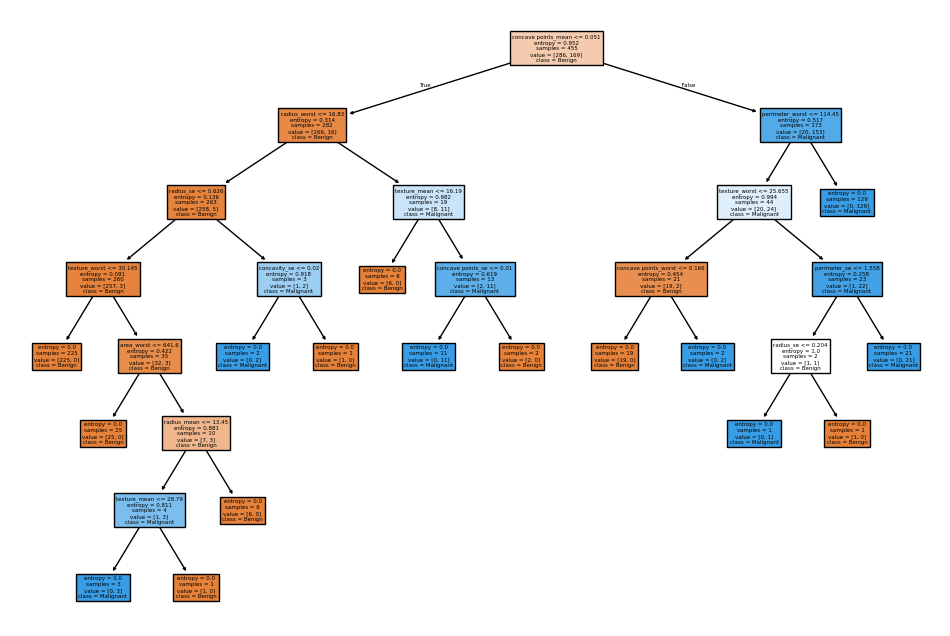

Accuracy: 93.85964912280701
classifiaction Report :
               precision    recall  f1-score   support

           0       0.93      0.97      0.95        71
           1       0.95      0.88      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



ValueError: 31 columns passed, passed data had 30 columns

In [ ]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')

data=pd.read_csv("./data.csv")
pd.set_option('display.max_columns',None)
print(data.head())
print(data.shape)
print(data.info())
print(data.isnull().sum())

df=data.drop(['id'],axis=1)
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
x=df.drop('diagnosis',axis=1)
y=df['diagnosis']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)

import math

def entropy(column):
    counts=column.value_counts()
    probabilities=counts/len(column)
    return -sum(probabilities*probabilities.apply(math.log2))

def conditional_entropy(data,x,target):
    feature_values=data[x].unique()
    weighted_entropy=0
    for value in feature_values:
        subset=data[data[x]==value]
        weighted_entropy+=(len(subset)/len(data))*entropy(subset[target])
    return weighted_entropy
def information_gain(data,x,target):
    total_entropy=entropy(data[target])
    feature_conditional_entropy=conditional_entropy(data,x,target)
    return total_entropy-feature_conditional_entropy

for feature in x.columns:
    ig=information_gain(df,feature,'diagnosis')
    print(f"Information Gain for {feature} : {ig}")

plt.figure(figsize=(12,8))
plot_tree(model,filled=True,feature_names=x.columns.tolist(),class_names=['Benign','Malignant'])
plt.show()

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)*100
classifiaction_rep=classification_report(y_test,y_pred)
print("Accuracy:",accuracy)
print("classifiaction Report :\n",classifiaction_rep)

new = [[12.5, 19.2, 80.0, 500.0, 0.085, 0.1, 0.05, 0.02, 0.17, 0.06, 
        0.4, 1.0, 2.5, 40.0, 0.006, 0.02, 0.03, 0.01, 0.02, 0.003, 
        16.0, 25.0, 105.0, 900.0, 0.13, 0.25, 0.28, 0.12, 0.29, 0.08]]

# ✔ Create DataFrame with SAME columns
new_df = pd.DataFrame(new, columns=x.columns)

# ✔ Predict
y_new_pred = model.predict(new_df)

if y_new_pred[0] == 0:
    print("Prediction: Benign")
else:
    print("Prediction: Malignant")


Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  fractal_dimension_mean  radius_se  te

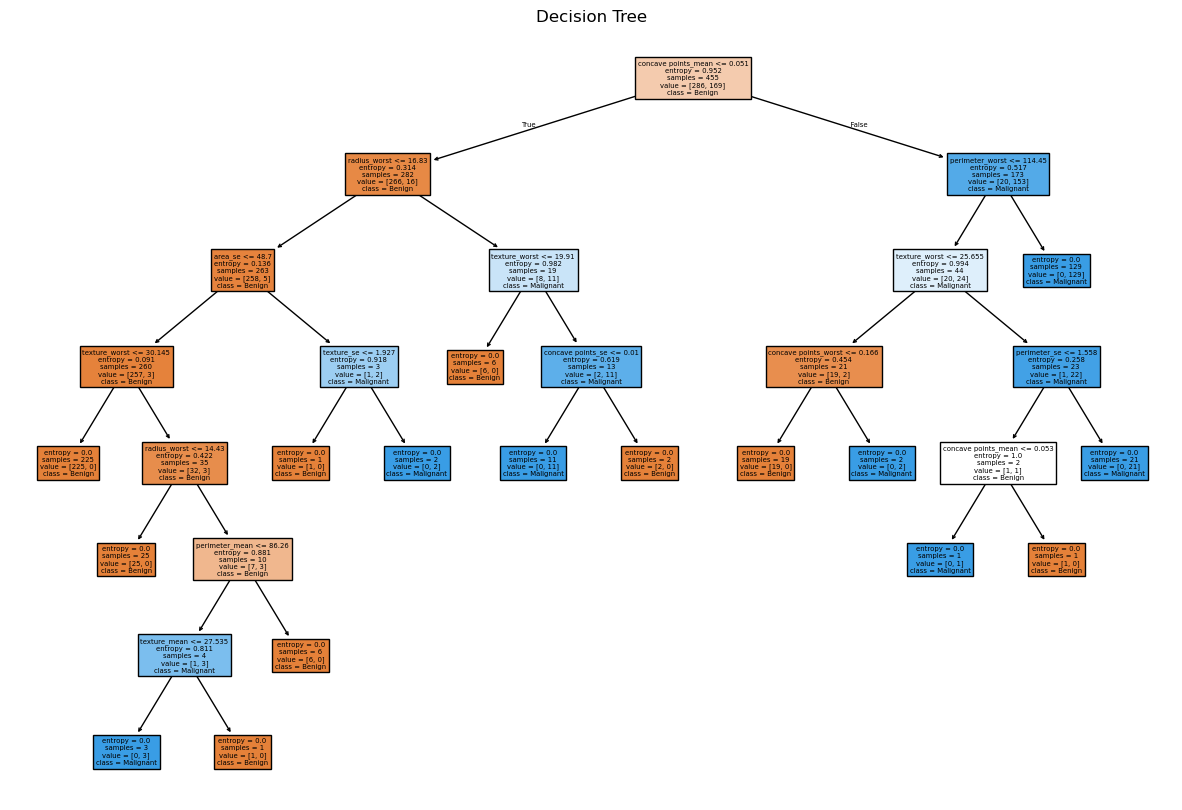


Accuracy: 94.74 %

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        71
           1       0.97      0.88      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114


Confusion Matrix:

[[70  1]
 [ 5 38]]

Prediction: Benign


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# 1. LOAD DATA
# -----------------------------
data = pd.read_csv("./data.csv")

pd.set_option('display.max_columns', None)

print("Head:\n", data.head())
print("\nShape:", data.shape)
print("\nInfo:")
print(data.info())
print("\nMissing Values:\n", data.isnull().sum())

# -----------------------------
# 2. DATA CLEANING
# -----------------------------
df = data.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# Convert target
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Split features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("\nTotal Features:", len(X.columns))

# -----------------------------
# 3. TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4. MODEL TRAINING
# -----------------------------
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# 5. ENTROPY & INFORMATION GAIN
# -----------------------------
import math

def entropy(column):
    counts = column.value_counts()
    probabilities = counts / len(column)
    return -sum(probabilities * probabilities.apply(lambda x: math.log2(x)))

def conditional_entropy(data, feature, target):
    values = data[feature].unique()
    weighted_entropy = 0

    for v in values:
        subset = data[data[feature] == v]
        weight = len(subset) / len(data)
        weighted_entropy += weight * entropy(subset[target])

    return weighted_entropy

def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    cond_entropy = conditional_entropy(data, feature, target)
    return total_entropy - cond_entropy

print("\n--- Information Gain ---")
for feature in X.columns:
    ig = information_gain(df, feature, 'diagnosis')
    print(f"{feature}: {ig:.4f}")

# -----------------------------
# 6. TREE VISUALIZATION
# -----------------------------
plt.figure(figsize=(15, 10))
plot_tree(
    model,
    filled=True,
    feature_names=X.columns.tolist(),
    class_names=['Benign', 'Malignant']
)
plt.title("Decision Tree")
plt.show()

# -----------------------------
# 7. MODEL EVALUATION
# -----------------------------
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100
print("\nAccuracy:", round(accuracy, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 8. NEW SAMPLE PREDICTION
# -----------------------------
new = [[
    12.5, 19.2, 80.0, 500.0, 0.085, 0.1, 0.05, 0.02, 0.17, 0.06,
    0.4, 1.0, 2.5, 40.0, 0.006, 0.02, 0.03, 0.01, 0.02, 0.003,
    16.0, 25.0, 105.0, 900.0, 0.13, 0.25, 0.28, 0.12, 0.29, 0.08
]]

# 🔥 Validate feature count
if len(new[0]) != len(X.columns):
    raise ValueError(f"Expected {len(X.columns)} features, but got {len(new[0])}")

new_df = pd.DataFrame(new, columns=X.columns)

prediction = model.predict(new_df)[0]

if prediction == 0:
    print("\nPrediction: Benign")
else:
    print("\nPrediction: Malignant")